In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

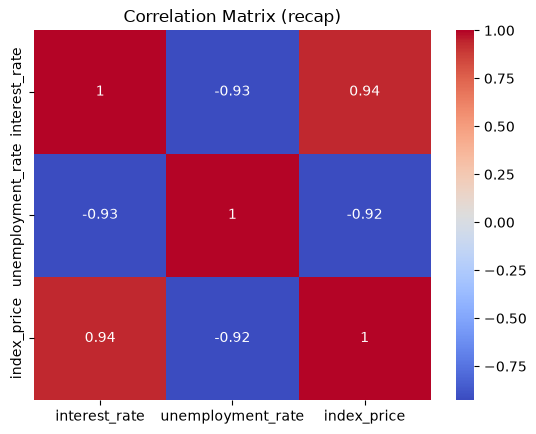

In [2]:

df = pd.read_csv('../data/economic_index.csv')
df = df.drop(columns=['Unnamed: 0', 'year', 'month'])

df.head()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (recap)')
plt.show()

In [3]:
#Split x and y
X = df[['interest_rate', 'unemployment_rate']]
y = df['index_price']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#Modeling: Ridge, Lasso & ElasticNet Side-by-Side
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

# Plain Linear Regression (baseline, for comparison)
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)


# ElasticNet
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic_model.fit(X_train_scaled, y_train)




,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [10]:
#Compare all coefficients side-by-side
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': linear_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'ElasticNet': elastic_model.coef_
})

print(coef_comparison)

             Feature      Linear       Ridge       Lasso  ElasticNet
0      interest_rate   86.633513   89.292159   86.165389   77.442683
1  unemployment_rate -114.048572 -106.028779 -113.478081  -81.320828


In [29]:
lasso_strong = Lasso(alpha=191.0)
lasso_strong.fit(X_train_scaled, y_train)

print("Lasso (alpha=50) coefficients:", lasso_strong.coef_)

Lasso (alpha=50) coefficients: [0. 0.]


In [30]:
#Cross-Validation Approach (finding the right alpha properly)
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

# LassoCV automatically tests a range of alphas using cross-validation
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("Best alpha found:", lasso_cv.alpha_)
print("Coefficients at best alpha:", lasso_cv.coef_)

Best alpha found: 0.19353560374964113
Coefficients at best alpha: [  86.58616553 -113.89847892]


In [31]:
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_cv.alpha_)
print("Ridge coefficients:", ridge_cv.coef_)

Best Ridge alpha: 1.0
Ridge coefficients: [  89.29215898 -106.02877904]


In [32]:
elastic_cv = ElasticNetCV(cv=5, random_state=42)
elastic_cv.fit(X_train_scaled, y_train)

print("Best ElasticNet alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)
print("ElasticNet coefficients:", elastic_cv.coef_)

Best ElasticNet alpha: 0.38707120749928225
Best l1_ratio: 0.5
ElasticNet coefficients: [ 86.96337966 -95.13950082]


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear': linear_model,
    'Ridge (CV)': ridge_cv,
    'Lasso (CV)': lasso_cv,
    'ElasticNet (CV)': elastic_cv
}

results = []

for name, m in models.items():
    y_pred = m.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

             Model        MAE       RMSE        R2
0           Linear  71.718784  83.409264  0.825494
1       Ridge (CV)  68.511218  79.937476  0.839719
2       Lasso (CV)  71.647238  83.321029  0.825863
3  ElasticNet (CV)  63.451742  75.762473  0.856024


In [35]:
import pickle

with open('../src/regularized_model.pkl', 'wb') as file:
    pickle.dump(ridge_cv, file)

with open('../src/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)